## Atmospheric Carbon Dioxide Dry Air Mole Fractions from quasi-continuous measurements at Mauna Loa, Hawaii.

In [1]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
from ipywidgets import interact
import pandas as pd
import seaborn as sns
import numpy as np

from darts import TimeSeries
from darts.dataprocessing.transformers.boxcox import BoxCox
from darts.utils.statistics import extract_trend_and_seasonality, ModelMode


sns.set_style("whitegrid")
Path.cwd()
data_dir = (Path.cwd().parent / ".data").resolve()
assert data_dir.exists()

In [2]:
def to_resampled_ts(df: pd.DataFrame, freq: str) -> TimeSeries:
    return (
        df.resample(freq)
        .mean()
        .interpolate(method="time")
        # drop NaNs at the end and beginning
        .dropna()
        .pipe(
            lambda df: TimeSeries.from_dataframe(
                df,
                value_cols=["value"],
                fill_missing_dates=True,
            )
        )
    )


df = (
    pd.read_csv(
        data_dir / "co2_mlo_surface-insitu_1_ccgg_DailyData.csv",
        sep=" ",
        header=158,
    )
    .assign(date=lambda df: pd.to_datetime(df["datetime"]))
    .drop(
        columns=[
            "year",
            "month",
            "day",
            "hour",
            "minute",
            "second",
            "datetime",
            "time_decimal",
            "midpoint_time",
        ]
    )  # drop redundant cols
    # replace invalid values with NaN
    .assign(
        **{
            col: lambda df, col=col: pd.to_numeric(df[col], errors="coerce").where(
                df[col] >= 0
            )
            for col in ("value", "value_std_dev", "intake_height")
        }
    )[["date", "value"]]
    .drop_duplicates(subset=["date"])
    .set_index("date")
)

ts_m, ts_d = to_resampled_ts(df, "ME"), to_resampled_ts(df, "D")

ts_m.n_timesteps, ts_d.n_timesteps

The provided DatetimeIndex was associated with a timezone, which is currently not supported by xarray. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone, which is currently not supported by xarray. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


(600, 18247)

<Axes: xlabel='date'>

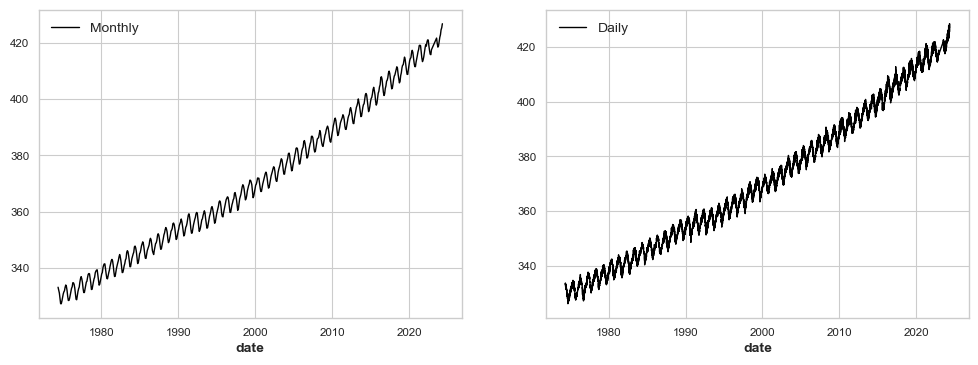

In [3]:
_, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

ts_m.plot(ax=ax0, label="Monthly", lw=1)
ts_d.plot(ax=ax1, label="Daily", lw=1)

## Ex 10
Use the a) MONTHLY b) DAILY AGGREGATED data (i.e. with a yearmonth date format) from your case study for this exercise.
- What Box-Cox transformation would you select for your time series?
- Compare the Box-Cox transformation to a log-transformation.
- Use additive and multiplicative classical_decomposition and compare the results. Do you think this decomposition is helpful here? 
- Do an STL decomposition of the data. Choose a seasonal window to allow for a changing shape of the seasonal component, if necessary. 
- Can you produce a plausible seasonally adjusted series?
- Tidy up your code, such that you would be happy to share it in class. And make sure that your code can be easily adapted to run on the data-sets from the other case studies.


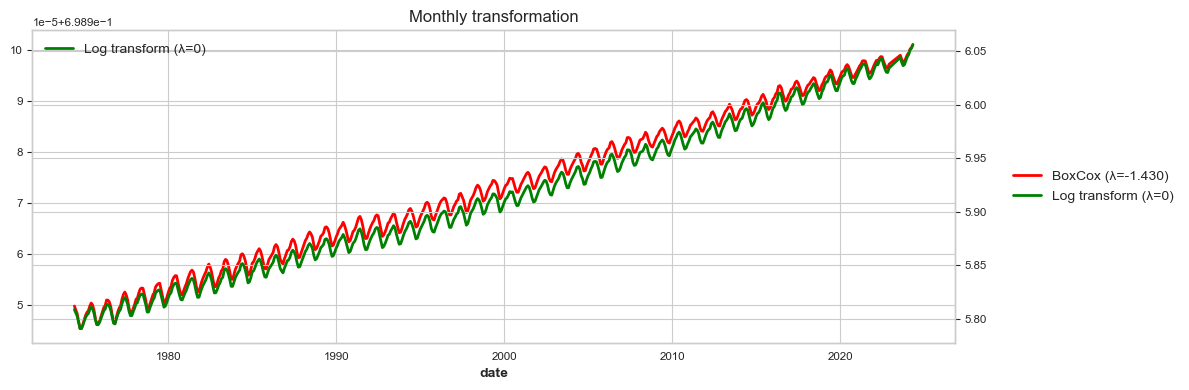

In [4]:
def compare_transformations(ts: TimeSeries, title="") -> tuple[TimeSeries, TimeSeries, BoxCox, BoxCox]:
    boxcox_auto = BoxCox()
    boxcox_log = BoxCox(lmbda=0)

    ts_auto = boxcox_auto.fit_transform(ts)
    ts_log = boxcox_log.fit_transform(ts)

    fitted_lambda = boxcox_auto._fitted_params[0][0]

    plt.figure(figsize=(12, 4))
    ax = ts_auto.plot(label=f'BoxCox (λ={fitted_lambda:.3f})', color='red')
    ax2 = ts_log.plot(ax=ax.twinx(), label='Log transform (λ=0)', color='green')
    ax.set_title(f"{title} transformation")

    # Get handles and labels from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    # Combine legends vertically
    ax.legend(lines1 + lines2, labels1 + labels2,
             loc='center left',
             bbox_to_anchor=(1.05, 0.5))

    plt.tight_layout()
    plt.show()

    return ts_auto, ts_log, boxcox_auto, boxcox_log

ts_m_box, ts_m_log, boxcox_m, log_m = compare_transformations(ts_m, "Monthly")

<Axes: xlabel='date'>

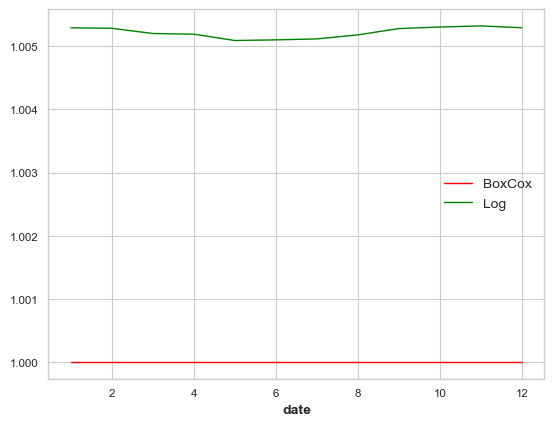

In [5]:
boxcox_m.inverse_transform(TimeSeries.from_dataframe(ts_m_box.pd_dataframe().groupby(ts_m_box.pd_dataframe().index.month).var())).plot(label='BoxCox', lw=1, color='red')
log_m.inverse_transform(TimeSeries.from_dataframe(ts_m_log.pd_dataframe().groupby(ts_m_log.pd_dataframe().index.month).var())).plot(label='Log', lw=1, color='green')


In [32]:
def plot_decomposition(ts: TimeSeries, trend: TimeSeries, seasonal: TimeSeries, transformer: BoxCox):
    # Calculate number of subplots needed (original + trend + n_seasonals + residual)
    n_plots = 2 + seasonal.n_components + 1

    _, ax = plt.subplots(n_plots, 1, figsize=(12, 3*n_plots))

    # Plot original series
    transformer.inverse_transform(ts).plot(ax=ax[0], lw=2, color="blue")
    ax[0].set_title("Original Series")

    # Plot trend
    transformer.inverse_transform(trend).plot(ax=ax[1], lw=2, color="orange")
    ax[1].set_title("Trend Component")

    # Plot each seasonal component separately
    if seasonal.n_components > 1:
        for i, cmp in enumerate(seasonal.components):
            transformer.inverse_transform(seasonal[cmp]).plot(ax=ax[2+i], lw=2, color="green")
            ax[2+i].set_title(f"Seasonal Component {i+1}")
    else:
        seasonal.plot(ax=ax[2], lw=2, color="green")
        ax[2].set_title("Seasonal Component")

    # Calculate residual by removing trend and sum of all seasonals
    all_seasonals = sum(seasonal[cmp] for cmp in seasonal.components) if seasonal.n_components > 1 else seasonal
    residual = transformer.inverse_transform(ts - trend - all_seasonals)

    # Plot residual
    residual.plot(ax=ax[-1], lw=2, color="red")
    ax[-1].set_title("Residual Component")

    plt.tight_layout()
    plt.show()

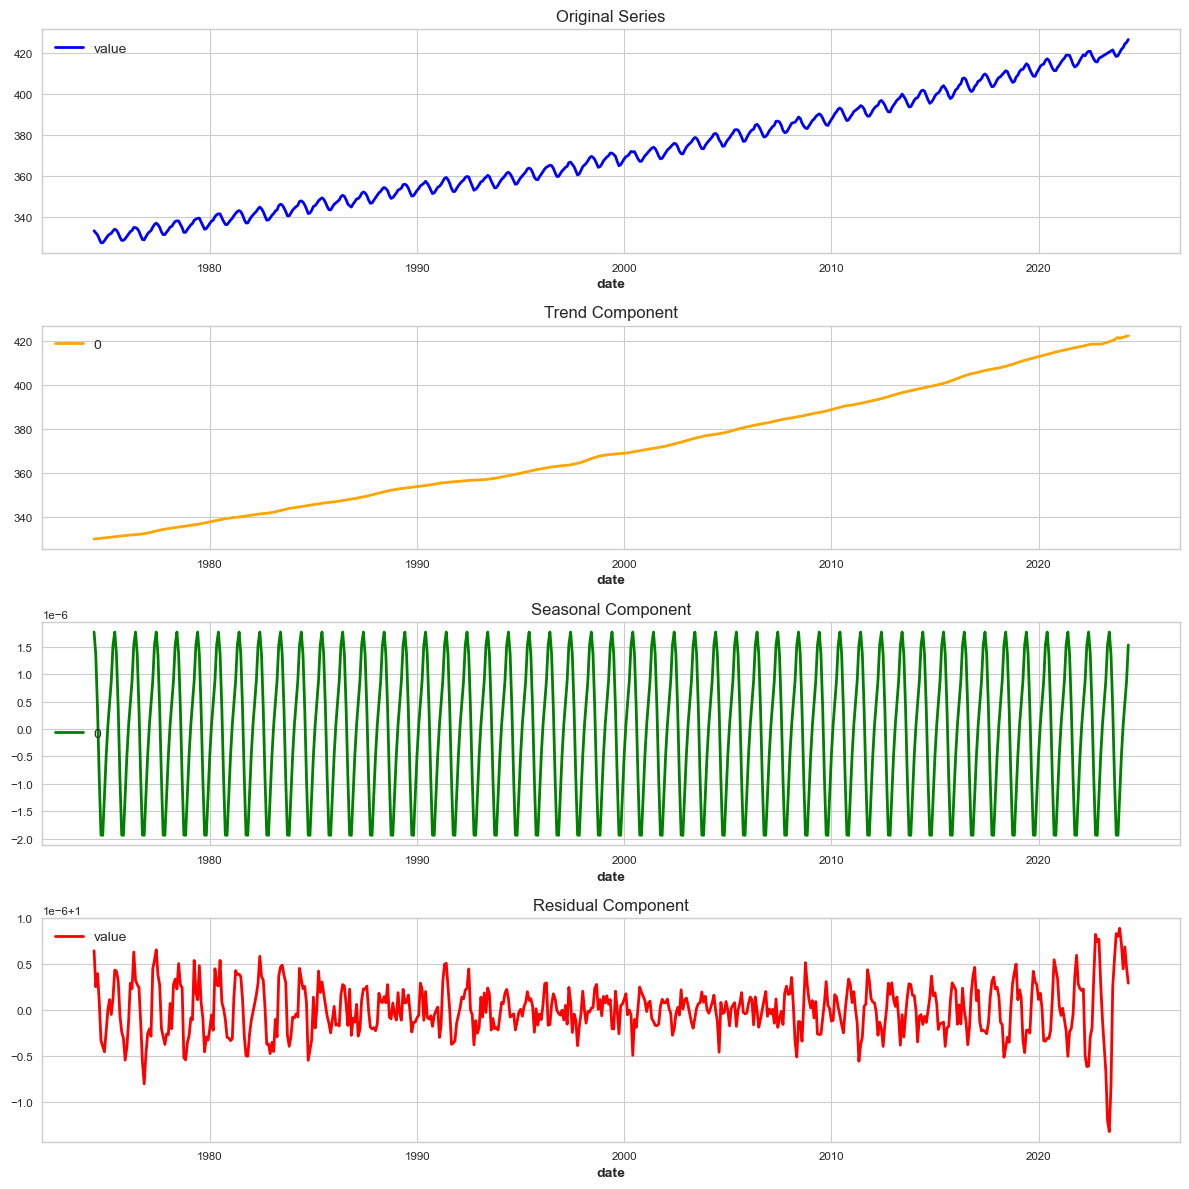

In [16]:
trend, seasonal = extract_trend_and_seasonality(ts_m_box, method="naive", model=ModelMode.ADDITIVE)

plot_decomposition(ts_m_box, trend, seasonal, boxcox_m)

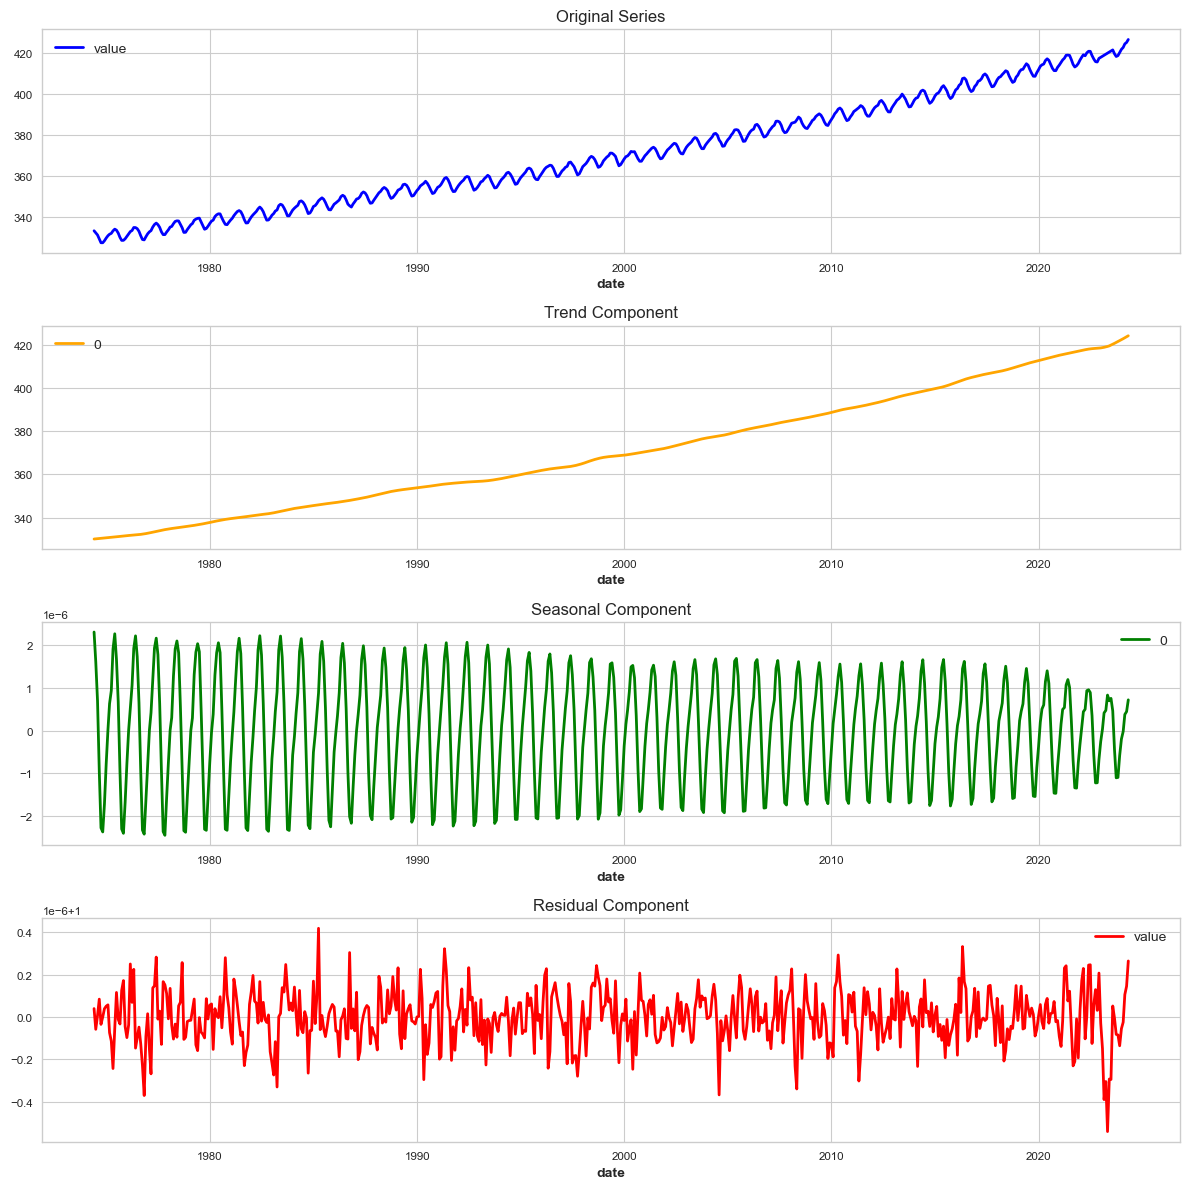

In [17]:
trend, seasonal = extract_trend_and_seasonality(ts_m_box, method="STL", model=ModelMode.ADDITIVE, freq=12)

plot_decomposition(ts_m_box, trend, seasonal, boxcox_m)

<Axes: xlabel='date'>

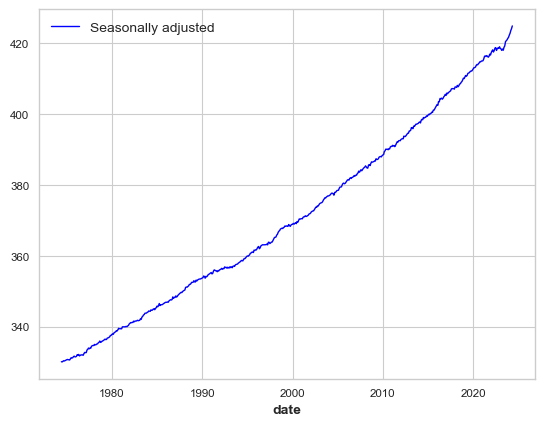

In [18]:
# Plot seasonally adjusted series
boxcox_m.inverse_transform(ts_m_box - seasonal).plot(label='Seasonally adjusted', lw=1, color='blue')

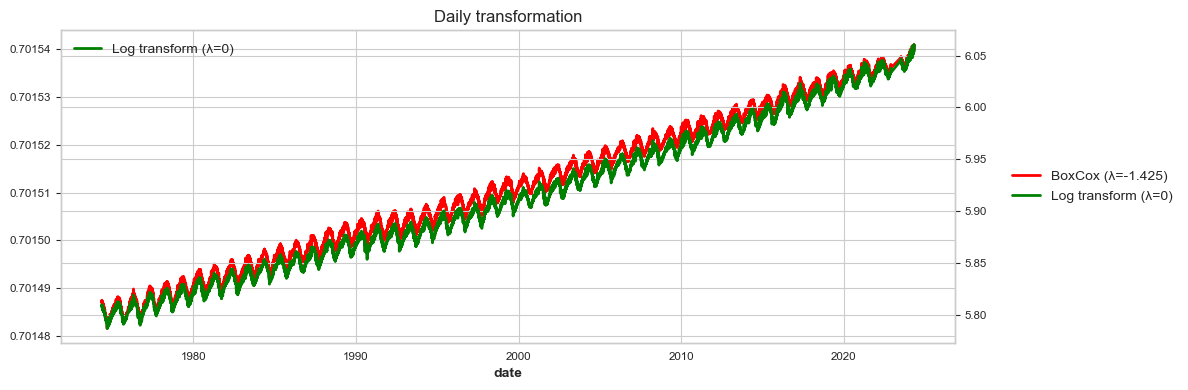

In [19]:
ts_d_box, ts_d_log, boxcox_d, log_d = compare_transformations(ts_d, "Daily")

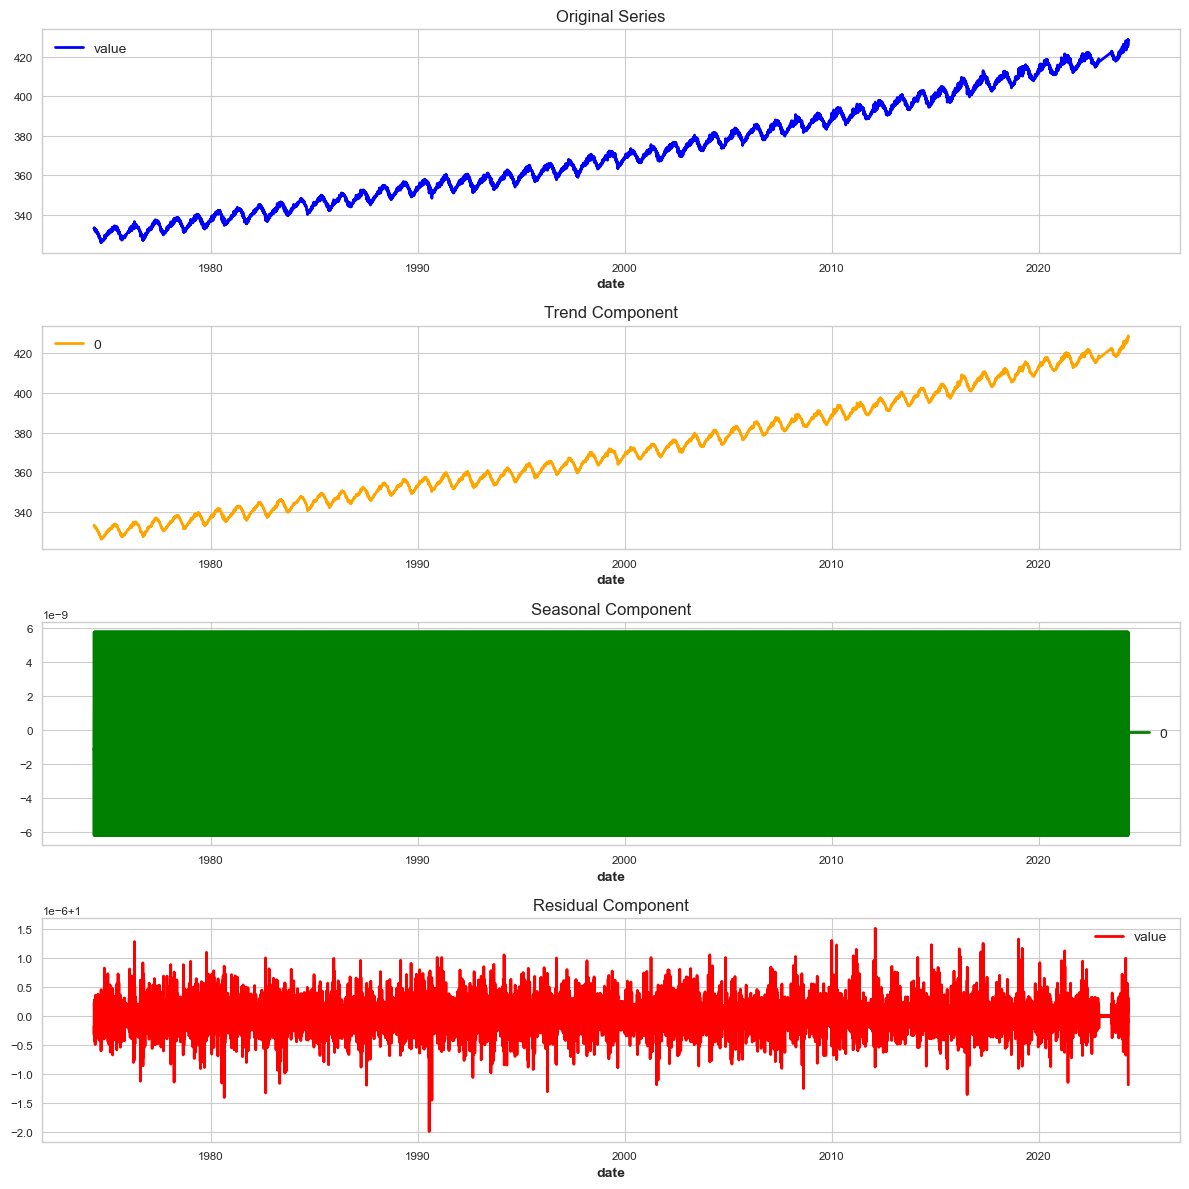

In [20]:
trend, seasonal = extract_trend_and_seasonality(ts_d_box, method="naive", model=ModelMode.ADDITIVE)

plot_decomposition(ts_d_box, trend, seasonal, boxcox_d)

In [27]:
trend, seasonal = extract_trend_and_seasonality(ts_d_box, method="MSTL", model=ModelMode.ADDITIVE, freq=[7, 365])

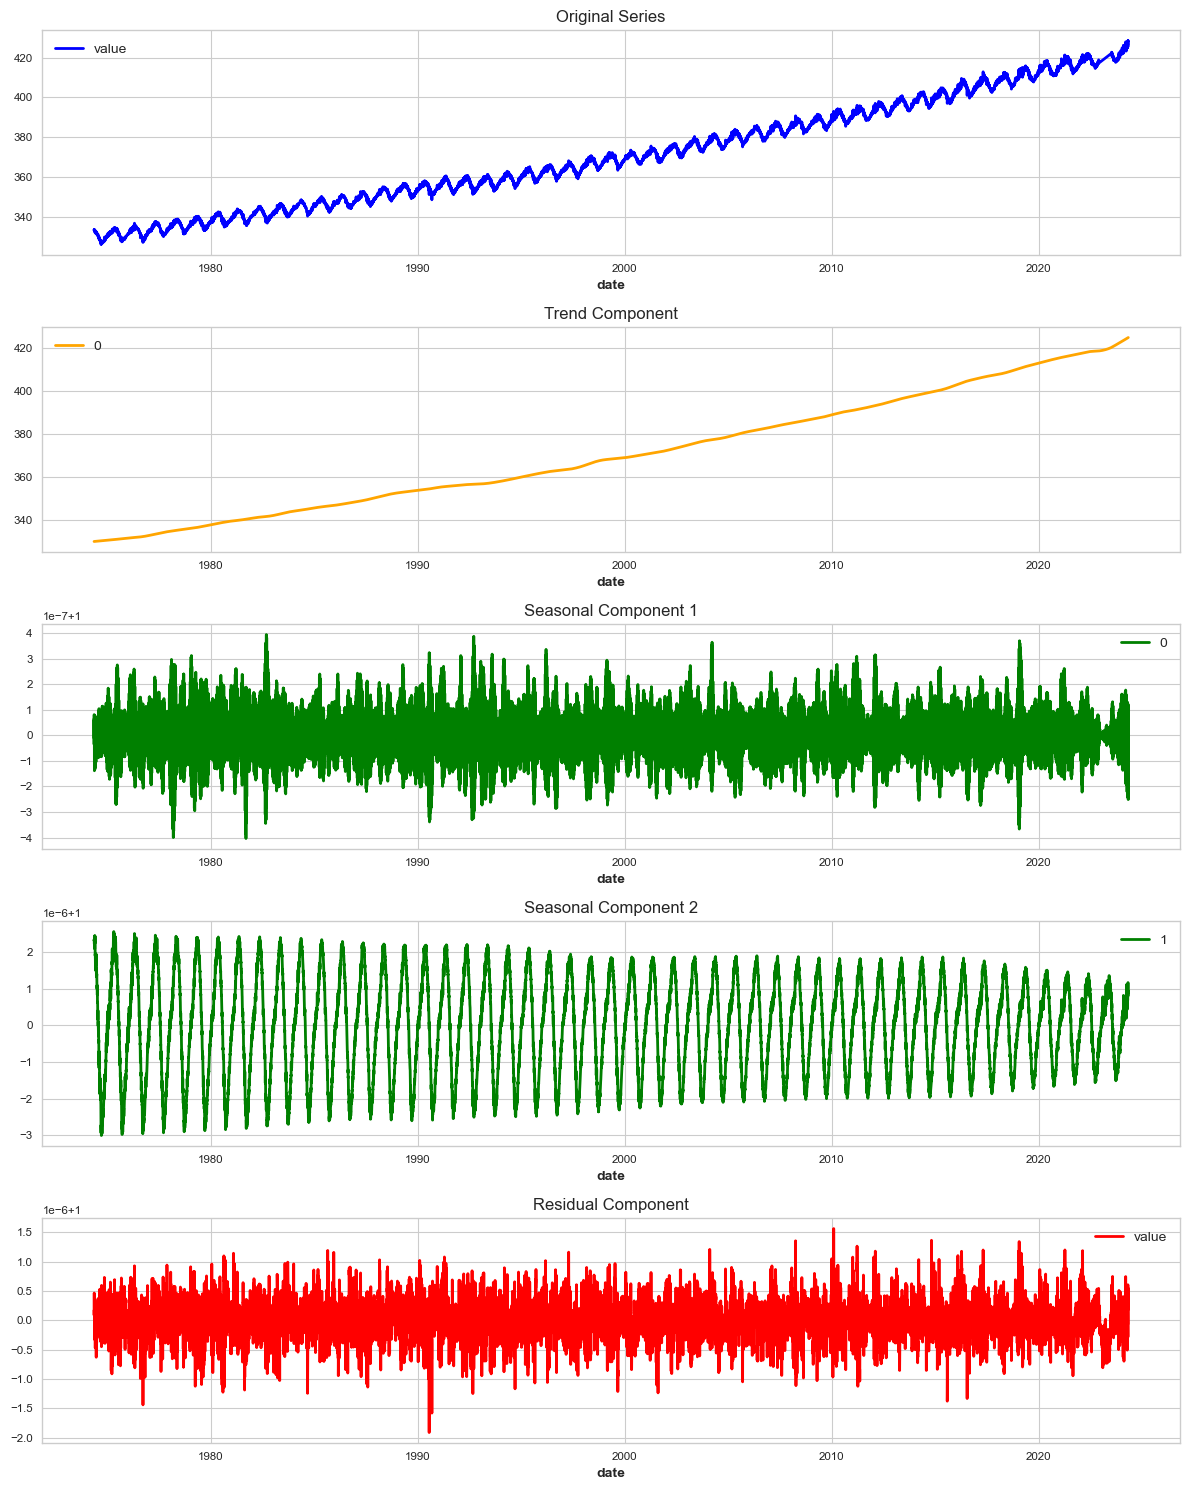

In [33]:
plot_decomposition(ts_d_box, trend, seasonal, boxcox_d)
# sum(seasonal[cmp] for cmp in seasonal.components)

<Axes: xlabel='date'>

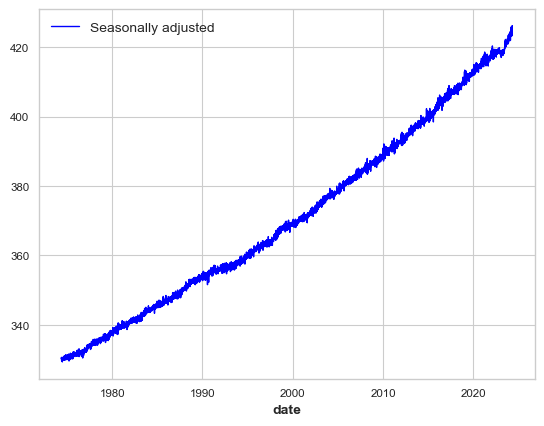

In [34]:
boxcox_d.inverse_transform(ts_d_box - sum(seasonal[cmp] for cmp in seasonal.components)).plot(label='Seasonally adjusted', lw=1, color='blue')

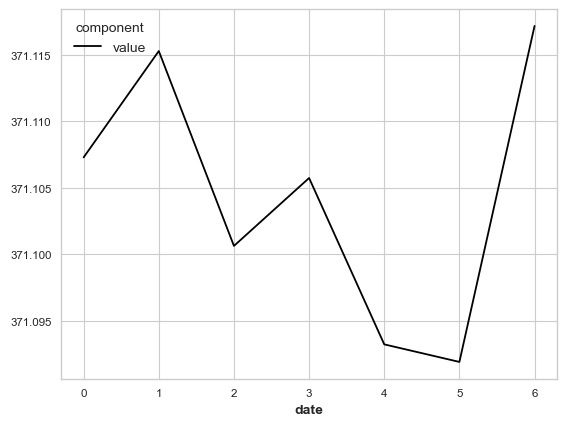

In [36]:
df = ts_d.pd_dataframe()
df = (
    df
    .groupby(df.index.dayofweek)
    .mean()
).plot()